This notebook loads the results from the runs in the 'experiments' directory and plots the load duration curves, along with a visualization of one day. Please make sure the results are available in the respective folders.

In [1]:
import dill
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr  # has classes for tick-locating and -formatting
from MultiBuildingRLEnv.finetuning.utils import gather_metrics_from_res

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
e:\Anaconda\envs\eaai2026\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def scale_to_hours(x, pos):  # your custom formatter function: divide by 100.0
    s = "{:.0f}".format((x * 720) / (2880))
    return s


xfmt = tkr.FuncFormatter(scale_to_hours)  # create your custom formatter function

In [3]:
start_date = "03/01/2022"
end_date = "04/30/2022"
t_start_date = "05/01/2022"
t_end_date = "05/30/2022"
end_date_p1 = "05/01/2022"
index = pd.date_range(start=start_date, end=end_date_p1, freq="15min", inclusive="left")

Load each result set

In [4]:
# Baseline
res_ref = dill.load(
    open(
        r"..\experiments\baseline\cons_100\res_baseline.dat",
        "rb",
    )
)
fix_lc = res_ref["res"]["net_load"].sort_values(ascending=False).to_numpy() / 1000.0

In [5]:
res_rl = dill.load(
    open(
        r"..\experiments\split_input_rl\cons_100\res_rl_split_input_rl_seed_1.dat",
        "rb",
    )
)
rl_lc = res_rl["res"]["net_load"].sort_values(ascending=False).to_numpy() / 1000.0

In [6]:
# Find the day with the biggest peak difference
avg_daily_peak = lambda nl: nl.to_numpy().reshape(-1, 96).max(axis=-1) / 4000.0
nl_rl = res_rl["res"]["net_load"] / 1000.0
nl_ref = res_ref["res"]["net_load"] / 1000.0
peak_diffs_sorted = np.arange(30)[
    np.argsort(avg_daily_peak(nl_rl) - avg_daily_peak(nl_ref))
]
day_idx = peak_diffs_sorted[2]
plt_idx = nl_rl.index[nl_rl.index.day == (day_idx + 1)]

In [7]:
# Save the control signals as well
start_idx, stop_idx = (
    nl_rl.index.get_loc(plt_idx[0]),
    nl_rl.index.get_loc(plt_idx[-1]),
)
price_matrix = np.array([cm.prices for cm in res_rl["cons_models"]])[
    :, start_idx : stop_idx + 1
]

In [8]:
res_tou = dill.load(
    open(
        r"..\experiments\precooling\cons_100\res_precooling.dat",
        "rb",
    )
)
met_tou = gather_metrics_from_res(res_tou)
tou_lc = res_tou["res"]["net_load"].sort_values(ascending=False).to_numpy() / 1000.0
nl_tou = res_tou["res"]["net_load"] / 1000.0
prix_tou = pd.Series(
    res_tou["cons_models"][1].prices, index=res_tou["res"]["net_load"].index
)

In [9]:
res_central = dill.load(
    open(
        r"..\experiments\centralized_rl\cons_100\res_rl_centralized_rl_seed_1.dat",
        "rb",
    )
)
nl_ctrl = res_central["res"]["net_load"] / 1000.0
ctrl_lc = (
    res_central["res"]["net_load"].sort_values(ascending=False).to_numpy() / 1000.0
)
ctrl_price_matrix = np.array([cm.prices for cm in res_central["cons_models"]])[
    :, start_idx : stop_idx + 1
]

In [10]:
res_dist = dill.load(
    open(
        r"..\experiments\distributed_rl\cons_100\res_rl_distributed_rl_seed_1.dat",
        "rb",
    )
)
nl_dist = res_dist["res"]["net_load"] / 1000.0
dist_lc = res_dist["res"]["net_load"].sort_values(ascending=False).to_numpy() / 1000.0
dist_price_matrix = np.array([cm.prices for cm in res_dist["cons_models"]])[
    :, start_idx : stop_idx + 1
]

C:\Users\shara\AppData\Local\Temp\ipykernel_31132\3030217326.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax_pg.set_xticklabels(ax_pg.get_xticks(), rotation=30)
C:\Users\shara\AppData\Local\Temp\ipykernel_31132\3030217326.py:169: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax_cs.set_xticklabels(ax_cs.get_xticks(), rotation=30)


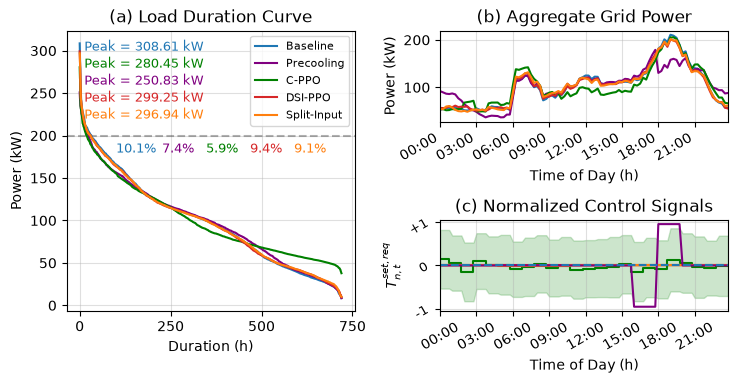

In [11]:
cm = 1 / 2.54  # centimeters in inches
c_rbc = "purple"

fig = plt.figure(figsize=(19 * cm, 10 * cm))
ax_ldc = plt.subplot(2, 2, (1, 3))
ax_cs = plt.subplot(2, 2, 4)
ax_pg = plt.subplot(2, 2, 2)

# Additional info on load duration curves
cutoffs = [200.0]  # [193.25]  # , 150, 100]
x_pos = np.array([100]) * (2880 / 720)
# cutoffs = [200, 150, 100]
# x_pos = np.array([100, 200, 350]) * (2880 / 720)
fix_cons, rl_cons, tou_cons, ctrl_cons, dist_cons = (
    fix_lc.sum(),
    rl_lc.sum(),
    tou_lc.sum(),
    ctrl_lc.sum(),
    dist_lc.sum(),
)
for ico, co in enumerate(cutoffs):
    ax_ldc.axhline(y=co, c="k", alpha=0.3, linestyle="--", linewidth=1.5)
    fix_cons_frac, rl_cons_frac, tou_cons_frac, ctrl_cons_frac, dist_cons_frac = (
        fix_lc[fix_lc > co].sum() / fix_cons,
        rl_lc[rl_lc > co].sum() / rl_cons,
        tou_lc[tou_lc > co].sum() / tou_cons,
        ctrl_lc[ctrl_lc > co].sum() / ctrl_cons,
        dist_lc[dist_lc > co].sum() / dist_cons,
    )
    t = ax_ldc.text(
        x_pos[ico], co - 20, f"{fix_cons_frac*100:.1f}%", color="C0", fontsize=9
    )
    ax_ldc.annotate(
        f"  {tou_cons_frac*100:.1f}%",
        color=c_rbc,
        xy=(0.95, 0),
        xycoords=t,
        va="bottom",
        fontsize=9,
    )
    ax_ldc.annotate(
        f"  {ctrl_cons_frac*100:.1f}%",
        color="g",
        xy=(2.05, 0),
        xycoords=t,
        va="bottom",
        fontsize=9,
    )
    ax_ldc.annotate(
        f"  {dist_cons_frac*100:.1f}%",
        color="C3",
        xy=(3.15, 0),
        xycoords=t,
        va="bottom",
        fontsize=9,
    )
    ax_ldc.annotate(
        f"  {rl_cons_frac*100:.1f}%",
        color="C1",
        xy=(4.25, 0),
        xycoords=t,
        va="bottom",
        fontsize=9,
    )
# Plot the load duration curves
ax_ldc.set(title="(a) Load Duration Curve", ylabel="Power (kW)", xlabel="Duration (h)")
ax_ldc.xaxis.set_major_formatter(xfmt)
# ax_ldc.text(15.0, max(fix_lc), f"Peak = {max(fix_lc):>5.2f} kW", c="C0", fontsize=9)
# ax_ldc.text(15.0, max(rl_lc) - 8, f"Peak = {max(rl_lc):>5.2f} kW", c="C1", fontsize=9)
# ax_ldc.text(
#     15.0, max(tou_lc) + 12, f"Peak = {max(tou_lc):>5.2f} kW", c=c_rbc, fontsize=9
# )
# ax_ldc.text(
#     15.0, max(ctrl_lc) + 3, f"Peak = {max(ctrl_lc):>5.2f} kW", c="g", fontsize=9
# )
# ax_ldc.text(
#     15.0, max(dist_lc), f"Peak = {max(dist_lc):>5.2f} kW", c="C3", fontsize=9
# )
text_xx_pos_ldc = 50.0
ax_ldc.text(
    text_xx_pos_ldc, 300.0, f"Peak = {max(fix_lc):>5.2f} kW", c="C0", fontsize=9
)
ax_ldc.text(
    text_xx_pos_ldc, 280.0, f"Peak = {max(ctrl_lc):>5.2f} kW", c="g", fontsize=9
)
ax_ldc.text(
    text_xx_pos_ldc, 260.0, f"Peak = {max(tou_lc):>5.2f} kW", c=c_rbc, fontsize=9
)
ax_ldc.text(
    text_xx_pos_ldc, 240.0, f"Peak = {max(dist_lc):>5.2f} kW", c="C3", fontsize=9
)
ax_ldc.text(text_xx_pos_ldc, 220.0, f"Peak = {max(rl_lc):>5.2f} kW", c="C1", fontsize=9)

ax_ldc.plot(fix_lc, label="Baseline")
ax_ldc.plot(tou_lc, label="Precooling", c=c_rbc)
ax_ldc.plot(ctrl_lc, label="C-PPO", c="g")
ax_ldc.plot(dist_lc, label="DSI-PPO", c="C3")
ax_ldc.plot(rl_lc, label="Split-Input")
ax_ldc.legend(loc="upper right", fontsize=8)
ax_ldc.grid(alpha=0.4)

# Plot the consumption for a day
ax_pg.set(
    title="(b) Aggregate Grid Power", ylabel="Power (kW)", xlabel="Time of Day (h)"
)
nl_ref[plt_idx].plot(ax=ax_pg, x_compat=True)
nl_tou[plt_idx].plot(ax=ax_pg, x_compat=True, c=c_rbc)
nl_ctrl[plt_idx].plot(ax=ax_pg, x_compat=True, c="g")
nl_dist[plt_idx].plot(ax=ax_pg, x_compat=True, c="C3")
nl_rl[plt_idx].plot(ax=ax_pg, x_compat=True, c="C1")
ax_pg.grid(alpha=0.4)
ax_pg.set_xlim(plt_idx[0], plt_idx[-1])

# Plot the RL control signals
ax_cs.set(
    title="(c) Normalized Control Signals",
    ylabel="$T^{set,req}_{n,t}$",
    xlabel="Time of Day (h)",
)
# Compute stats for controlled price matrix
ctrl_mean = np.clip(ctrl_price_matrix.mean(axis=0), -1, 1)
ctrl_std = np.clip(ctrl_price_matrix.std(axis=0), 0, 1)

# Compute stats for controlled price matrix
dist_mean = np.clip(dist_price_matrix.mean(axis=0), -1, 1)
dist_std = np.clip(dist_price_matrix.std(axis=0), 0, 1)

# Compute stats for baseline price matrix
base_mean = np.clip(price_matrix.mean(axis=0), -1, 1)
base_std = np.clip(price_matrix.std(axis=0), 0, 1)

# Plot controlled price
ax_cs.step(plt_idx, ctrl_mean, c="g", label="Controlled")
ax_cs.fill_between(
    plt_idx,
    np.clip(ctrl_mean - ctrl_std, -1, 1),
    np.clip(ctrl_mean + ctrl_std, -1, 1),
    color="g",
    alpha=0.2,
)

# Plot controlled price
ax_cs.step(plt_idx, dist_mean, c="C3", label="Controlled")
ax_cs.fill_between(
    plt_idx,
    np.clip(dist_mean - dist_std, -1, 1),
    np.clip(dist_mean + dist_std, -1, 1),
    color="C3",
    alpha=0.2,
)

# Plot baseline price
ax_cs.step(plt_idx, base_mean, c="C1", label="Baseline")
ax_cs.fill_between(
    plt_idx,
    np.clip(base_mean - base_std, -1, 1),
    np.clip(base_mean + base_std, -1, 1),
    color="C1",
    alpha=0.2,
)
tou_norm = (prix_tou[plt_idx].to_numpy() * 100).clip(-1, 1)
ax_cs.plot(plt_idx, tou_norm, c=c_rbc)
ax_cs.set_xlim(plt_idx[0], plt_idx[-1])
# prix_tou[plt_idx].plot(ax=ax_cs, c=c_rbc)
ax_cs.axhline(y=0, linestyle="--", c="C0")
ax_cs.grid(alpha=0.4)

ax_pg.set_xticklabels(ax_pg.get_xticks(), rotation=30)
ax_cs.set_xticklabels(ax_cs.get_xticks(), rotation=30)
ax_cs.set_yticks([-1.05, 0, 1.05], labels=["-1", "0", "+1"], rotation=30, fontsize=9)
ax_cs.set_ylim(-1.1, 1.1)
ax_pg.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%H:%M"))
ax_cs.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%H:%M"))

fig.tight_layout()
# fig.savefig("export/load_duration_curve_all.png", dpi=400, bbox_inches="tight")

In [12]:
new_rc_params = {"text.usetex": False, "svg.fonttype": "none"}
matplotlib.rcParams.update(new_rc_params)
fig.savefig("figures/load_duration_curve.svg", bbox_inches="tight")